In [13]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
# from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
# from python.misprediction_classifier import *
from autoencoder.src.data_loader import *
from interpolate import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


# Load data

In [2]:
# pred_result_folder = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/correction/results'
# pred_result_path = os.path.join(pred_result_folder, 'pred_results_w_first_frame_v1.npy')
# pred_result = np.load(pred_result_path)
# print(pred_result.shape)
pred_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred.slp'
pred_dataset = sleap.load_file(pred_dataset_path)
pred_result = get_all_untracked_points(pred_dataset, interpolate=False, use_labeled_only=False, reorder=False, start_idx=0, tb_cnt=None)
print(pred_result.shape)

corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_corrected_with_scores_simplemax.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_tracked_points(corrected_dataset, interpolate=False, use_labeled_only=False, reorder=False, start_idx=0)

tb_cnt: 22
all_untracked_points shape: (3000, 22, 2)


3000it [00:03, 812.44it/s]


Missing point count: 12602
(3000, 22, 2)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (3000, 17, 2)
First non missing frame idx: 0
Missing point count: 0


In [28]:
pred_missing_mask = get_missing_count(pred_result)
print(f'missing count: {np.sum(pred_missing_mask)}')

missing count: 9107.0


In [51]:
np.where(pred_missing_mask > 7)[0]

array([], dtype=int64)

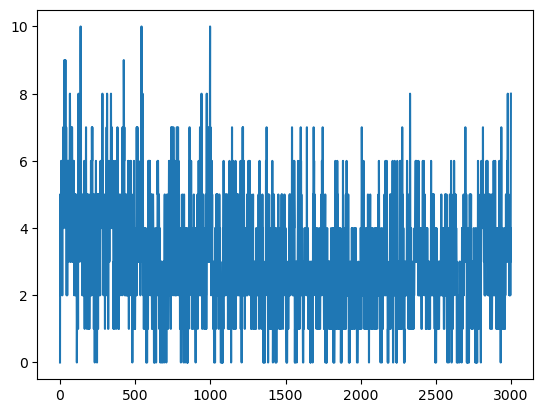

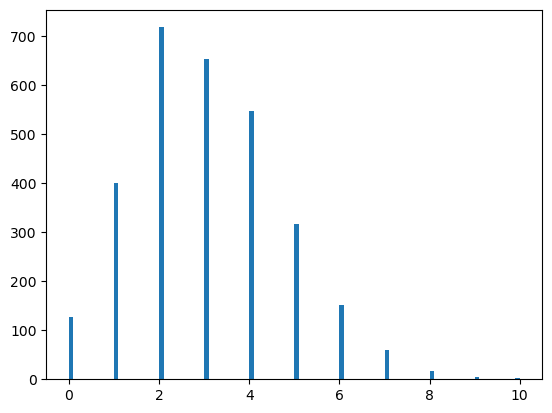

In [50]:
pred_missing_cnt_per_frame = np.sum(pred_missing_mask, axis=1)
plt.plot(pred_missing_cnt_per_frame)
plt.show()
plt.hist(pred_missing_cnt_per_frame.flatten(), bins=100)
plt.show()


In [52]:
np.where(pred_missing_cnt_per_frame > 7)[0]

array([  29,   30,   32,   36,   66,  123,  136,  137,  138,  282,  313,
        339,  424,  425,  541,  542,  549,  941,  976,  997,  998, 2328,
       2978, 2999])

# Pre-align/interpolate

1. For each non-missing point, find its nearest neighbor (?) in the previous frame. Assign ID. 
    - greedy/hangarian?
2. Non-assigned IDs are missing in the current frame. Use coordinates from the previous frame as place holder.
    - still labeled as missing
    - assume no missing points in the first frame

In [7]:
def align_pts_order(pred_pts, gt_pts, frame_idx=0):
    pred_pts = pred_pts[frame_idx, :, :2]
    gt_pts = gt_pts[frame_idx, :, :2]
    pred_pt_cnt = pred_pts.shape[0]
    id_mapping = np.full(pred_pt_cnt, -1)
    dist_queue = [] # (dist, pt_idx, nn_idx)
    used_nn = []
    for pt_idx in range(pred_pt_cnt): # prediction could have more points than gt; only matches will be used 
        curr_pt = pred_pts[pt_idx]
        dists = np.linalg.norm(gt_pts - curr_pt, axis=1)
        min_dist_idx = np.argmin(dists)
        dist_queue.append((dists[min_dist_idx], pt_idx, min_dist_idx))
    dist_queue.sort(key=lambda x: x[0])
    
    for _, pt_idx, nn_idx in dist_queue:
        if nn_idx not in used_nn:
            used_nn.append(nn_idx)
            id_mapping[pt_idx] = nn_idx
    # assert np.all(id_mapping != -1), f'some points are not assigned to any gt point'
    return id_mapping

def assign_ids(pred_pts, dist_thres=5, pt_cnt=17, manual_align=True, manual_align_idx=0):
    pred_pts = pred_pts[:, :, :2]
    frame_cnt, pred_pt_cnt = pred_pts.shape[:2]
    id_pts = np.zeros((frame_cnt, pt_cnt, 2))
    missing_mask = np.zeros((frame_cnt, pt_cnt), dtype=bool)
    
    if manual_align:
        id_mapping = align_pts_order(pred_pts, gt_pts, frame_idx=manual_align_idx)
        for i, map_idx in enumerate(id_mapping):
            if map_idx != -1:
                id_pts[manual_align_idx, map_idx] = pred_pts[manual_align_idx, i]
    else:
        id_pts[0] = pred_pts[0]
    
    for frame_idx in range(1, frame_cnt): # assume first frame has all points and in the right order
        # pred_curr_frame_pts = pred_pts[frame_idx]
        prev_frame_pts = id_pts[frame_idx - 1]
        dist_queue = [] # (dist, pt_idx, nn_idx)
        used_nn = []
        
        for pt_idx in range(pred_pt_cnt):
            curr_pt = pred_pts[frame_idx, pt_idx]
            dists = np.linalg.norm(prev_frame_pts - curr_pt, axis=1)
            min_dist_idx = np.argmin(dists)
            dist_queue.append((dists[min_dist_idx], pt_idx, min_dist_idx))
            
        dist_queue.sort(key=lambda x: x[0])
        
        for dist, pt_idx, nn_idx in dist_queue:
            if dist > dist_thres:
                break
            if nn_idx not in used_nn:
                used_nn.append(nn_idx)
                id_pts[frame_idx, nn_idx] = pred_pts[frame_idx, pt_idx]
        
        for pt_idx in range(pt_cnt):
            if id_pts[frame_idx, pt_idx].sum() == 0:
                id_pts[frame_idx, pt_idx] = prev_frame_pts[pt_idx]
                missing_mask[frame_idx, pt_idx] = 1
                
    return id_pts, missing_mask

In [8]:
pred_result_w_ids, id_missing_mask = assign_ids(pred_result, dist_thres=6)
print(id_missing_mask.sum())

4141


In [12]:
pred_id_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred_id.slp'
pred_id_dataset = multi_model_dataset_with_points(pred_dataset, pred_result_w_ids, with_score=False, add_track=True)
pred_id_dataset.save(pred_id_path)

Tentacle count: 17


(3000,)


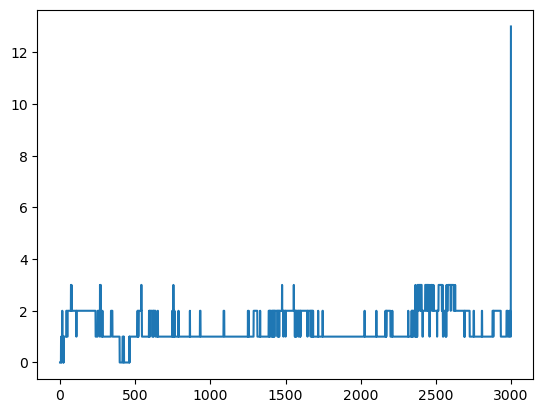

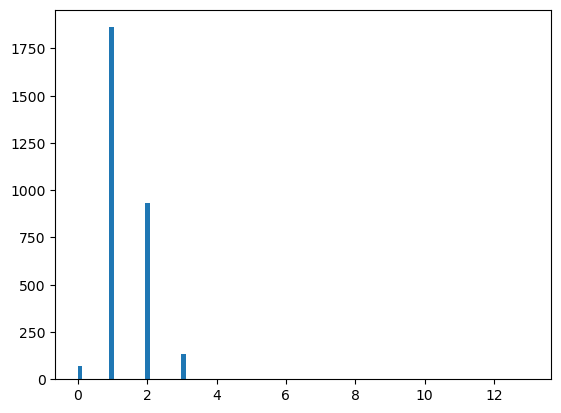

In [9]:
id_missing_cnt_per_frame = np.sum(id_missing_mask, axis=1)
print(id_missing_cnt_per_frame.shape)
plt.plot(id_missing_cnt_per_frame)
plt.show()
plt.hist(id_missing_cnt_per_frame.flatten(), bins=100)
plt.show()

In [83]:
np.argmax(id_missing_cnt_per_frame), np.max(id_missing_cnt_per_frame), id_missing_cnt_per_frame[0]

(73, 1, 0)

In [6]:
print(np.isclose(pred_result_w_ids[0], gt_pts[0], atol=1e-3).all())

True


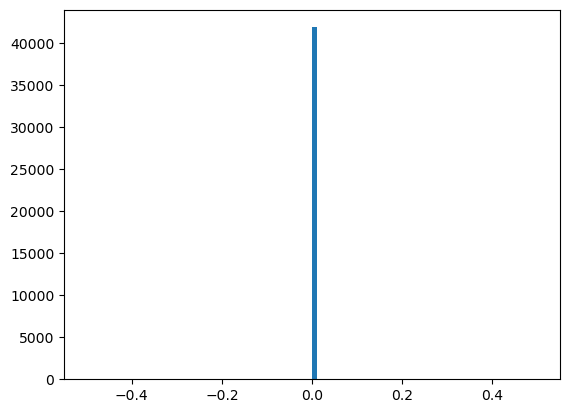

mean: 0.0, std: 0.0, max: 0.0


In [46]:
plot_nn_err(pred_result_w_ids, id_missing_mask=~id_missing_mask, gt_pts=gt_pts, use_non_overlap_nn=True)

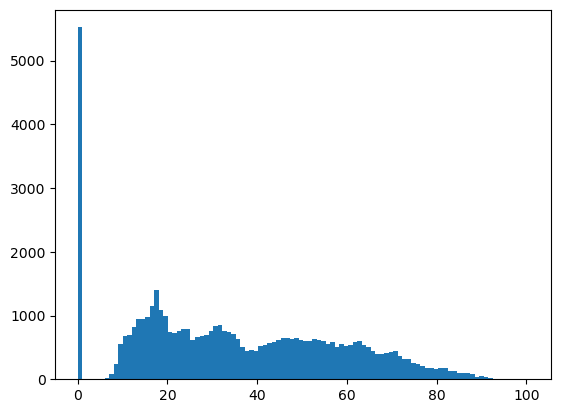

mean: 35.17605752103929, std: 23.03442973549665, max: 100.52331193128514


In [76]:
plot_poly_err(pred_result_w_ids, id_missing_mask=~id_missing_mask, gt_pts=gt_pts)

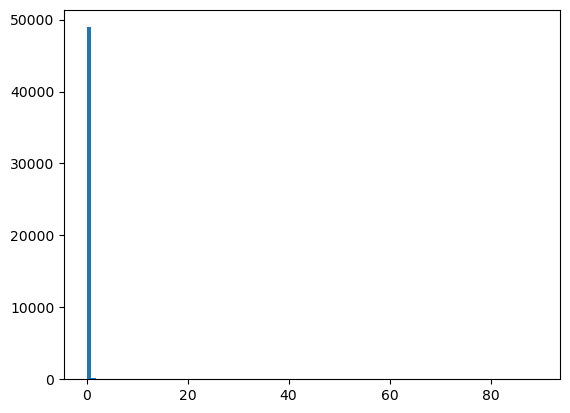

mean: 1.0702515384744142, std: 6.757015400936469, max: 89.30788703823544


In [79]:
plot_nn_err(pred_result_w_ids, id_missing_mask=None, gt_pts=gt_pts, use_non_overlap_nn=True)

# Interpolate

In [11]:
pred_result_interpolated = avg_flow_interpolate(pred_result_w_ids, window_size=4, verbose=False, non_missing_mask=~id_missing_mask)

In [15]:
result_dir = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/correction/results'
pred_id_path = os.path.join(result_dir, 'pred_results_w_ids.npy')
np.save(pred_id_path, pred_result_w_ids)

In [17]:
pred_result_w_ids.shape

(3000, 17, 2)

In [7]:
pred_result_polar_interpolated = polar_interpolate(pred_result_w_ids, verbose=False, non_missing_mask=~id_missing_mask)

In [12]:
pred_interp_missing_mask = get_missing_count(pred_result_interpolated)
print(f'missing count: {np.sum(pred_interp_missing_mask)}')

missing count: 0.0


In [21]:
arr = np.array([1, 2, 3, 4, 5])
arr = np.delete(arr, 0, axis=0)
print(arr)

[2 3 4 5]


In [22]:
def get_gt_pts(corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'):
    corrected_dataset = sleap.load_file(corrected_dataset_path)
    return get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

def plot_nn_err(pred_pts, id_missing_mask=None, gt_pts=None, use_non_overlap_nn=False):
    # if id_missing_mask is None, calculate error for all points
    if gt_pts is None:
        gt_pts = get_gt_pts()
    frame_cnt, pt_cnt = pred_pts.shape[:2]
    all_err = []
    for frame_idx in range(frame_cnt):
        curr_pts = gt_pts[frame_idx]
        if use_non_overlap_nn:
            curr_pts = curr_pts.copy()
            
        for pt_idx in range(pt_cnt):
            if id_missing_mask is None or id_missing_mask[frame_idx, pt_idx] == 1:  
                all_dists = np.linalg.norm(pred_pts[frame_idx, pt_idx] - curr_pts, axis=1)
                min_dist_idx = np.argmin(all_dists)
                all_err.append(all_dists[min_dist_idx])
                if use_non_overlap_nn:
                    curr_pts = np.delete(curr_pts, min_dist_idx, axis=0)
                    
    all_err = np.array(all_err)
    plt.hist(all_err.flatten(), bins=100)
    plt.show()
    print(f'mean: {np.mean(all_err)}, std: {np.std(all_err)}, max: {np.max(all_err)}')

def plot_poly_err(pred_pts, id_missing_mask=None, gt_pts=None):
    if gt_pts is None:
        gt_pts = get_gt_pts()
    all_interp_err = pred_pts - gt_pts
    if id_missing_mask is not None:
        all_interp_err = all_interp_err[id_missing_mask > 0]
    all_interp_err = np.linalg.norm(all_interp_err, axis=1)
    plt.hist(all_interp_err.flatten(), bins=100)
    plt.show()
    print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

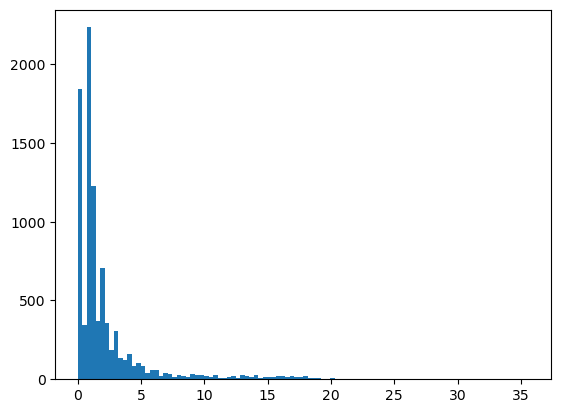

mean: 2.3088291384364577, std: 3.509209053408357, max: 35.61927687884356


In [23]:
plot_nn_err(pred_result_w_ids, id_missing_mask=id_missing_mask, gt_pts=gt_pts, use_non_overlap_nn=True)

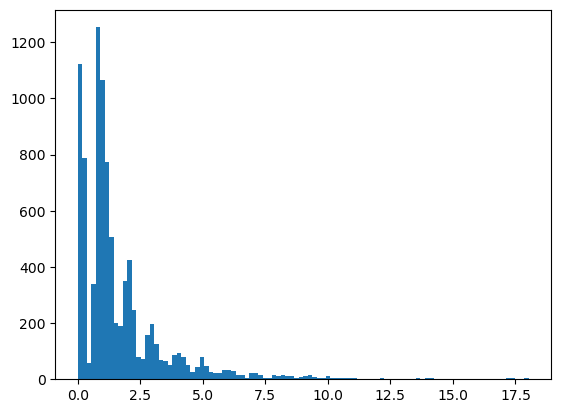

mean: 1.71673945605826, std: 2.024537088342878, max: 18.02803547094674


In [14]:
plot_nn_err(pred_result_w_ids, id_missing_mask=id_missing_mask, gt_pts=gt_pts)

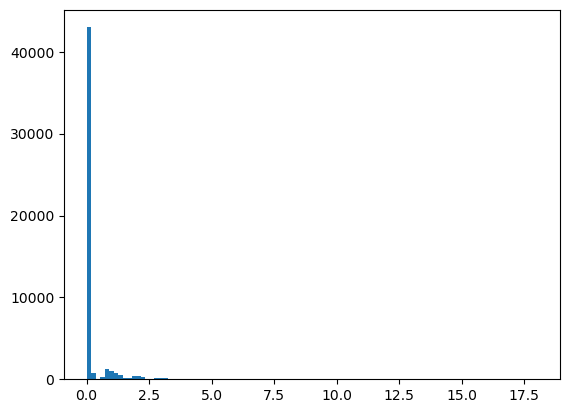

mean: 0.3072963626344285, std: 1.0801819575890623, max: 18.02803547094674


In [15]:
plot_nn_err(pred_result_w_ids, id_missing_mask=None, gt_pts=gt_pts)

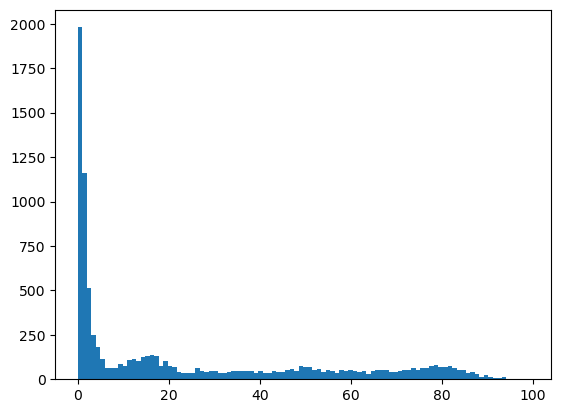

mean: 24.593850682251606, std: 28.62190585491934, max: 99.09608465416335


In [19]:
plot_poly_err(pred_result_w_ids, id_missing_mask=id_missing_mask, gt_pts=gt_pts)

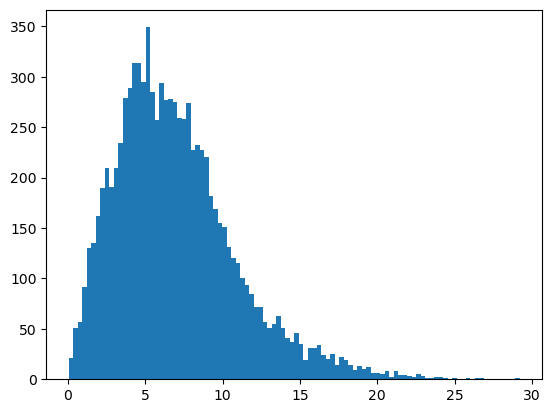

mean: 6.989386024742587, std: 3.9161639162810635, max: 29.212229725816343


In [8]:
all_err = []
pred_result_interpolated = pred_result_polar_interpolated
frame_cnt, pt_cnt = pred_result_interpolated.shape[:2]
for frame_idx in range(frame_cnt):
    for pt_idx in range(pt_cnt):
        if id_missing_mask[frame_idx, pt_idx] == 1:
            min_dist = np.min(np.linalg.norm(pred_result_interpolated[frame_idx, pt_idx] - gt_pts[frame_idx], axis=1))
            all_err.append(min_dist)
all_err = np.array(all_err)
plt.hist(all_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_err)}, std: {np.std(all_err)}, max: {np.max(all_err)}')


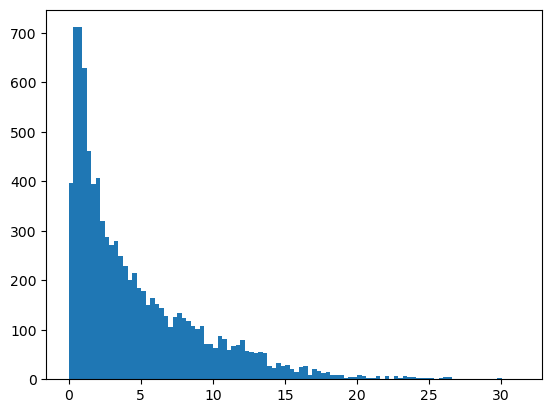

mean: 4.661532858716379, std: 4.5357214686769565, max: 31.28508303692826


In [13]:
all_err = []
frame_cnt, pt_cnt = pred_result_interpolated.shape[:2]
for frame_idx in range(frame_cnt):
    for pt_idx in range(pt_cnt):
        if id_missing_mask[frame_idx, pt_idx] == 1:
            min_dist = np.min(np.linalg.norm(pred_result_interpolated[frame_idx, pt_idx] - gt_pts[frame_idx], axis=1))
            all_err.append(min_dist)
all_err = np.array(all_err)
plt.hist(all_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_err)}, std: {np.std(all_err)}, max: {np.max(all_err)}')


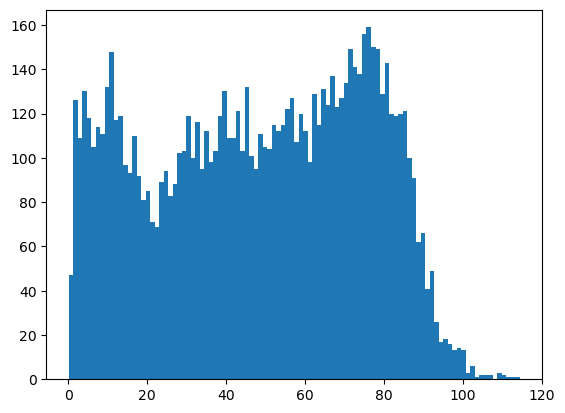

mean: 48.143761273682856, std: 26.7252779471961, max: 114.44609287780244


In [9]:
all_interp_err = np.linalg.norm((pred_result_polar_interpolated - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

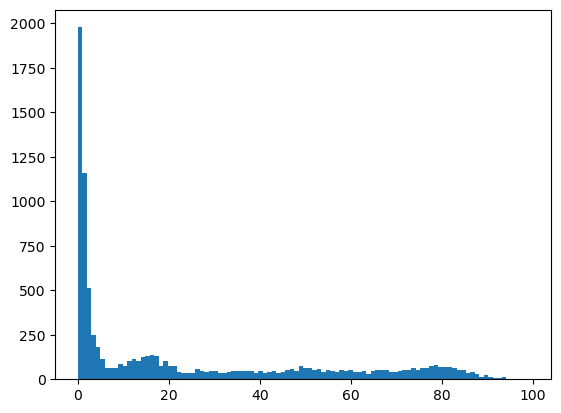

mean: 24.49698085570203, std: 28.573398369700936, max: 99.09608465416335


In [23]:
all_interp_err = np.linalg.norm((pred_result_interpolated - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

In [14]:
pred_result_interpolated_poly = polygon_correction_with_points(pred_result_interpolated)

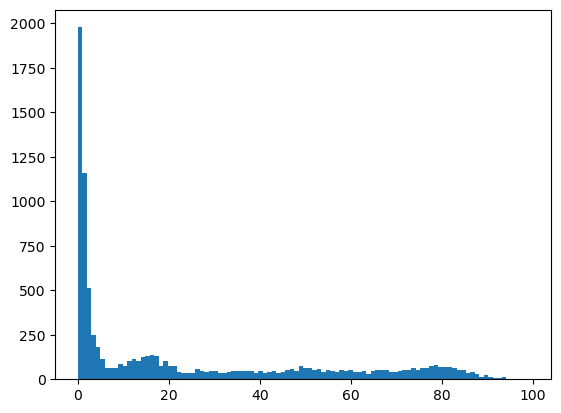

mean: 24.49698085570203, std: 28.573398369700936, max: 99.09608465416335


In [11]:
all_interp_err = np.linalg.norm((pred_result_w_ids - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

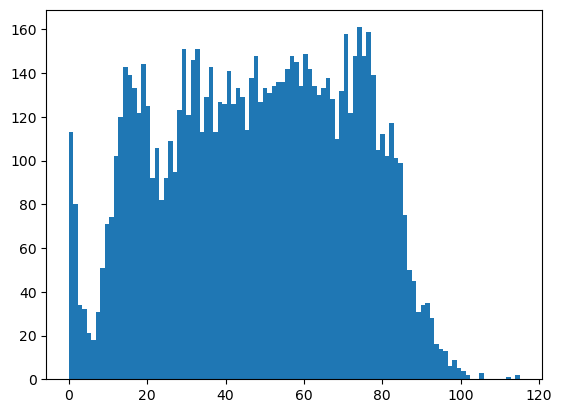

mean: 48.064415787610244, std: 23.871785160551237, max: 115.06862945150792


In [15]:
all_interp_err = np.linalg.norm((pred_result_interpolated_poly - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

In [13]:
vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/animal_1_1h_20s.mp4'
vid = video_loader(vid_path)
print(vid.shape, vid.min(), vid.max())

(3000, 170, 174) 0.00784313725490196 1.0


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/polar_interp_test_animation.mp4
Animation saved to /home/mingxiao/Desktop/animation/polar_interp_test_animation.mp4


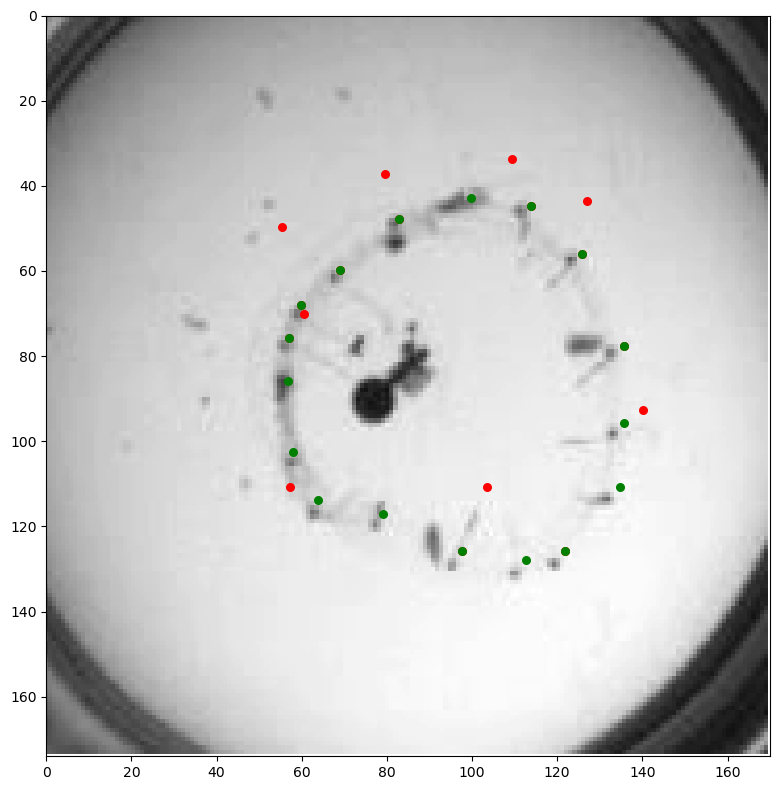

In [16]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}
interp_test_animation_path = '/home/mingxiao/Desktop/animation/polar_interp_test_animation.mp4'
animate_classification_results(pred_result_polar_interpolated, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                               bg_video=vid, bg_video_start_idx=0)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/interp_test_animation.mp4
Animation saved to /home/mingxiao/Desktop/animation/interp_test_animation.mp4


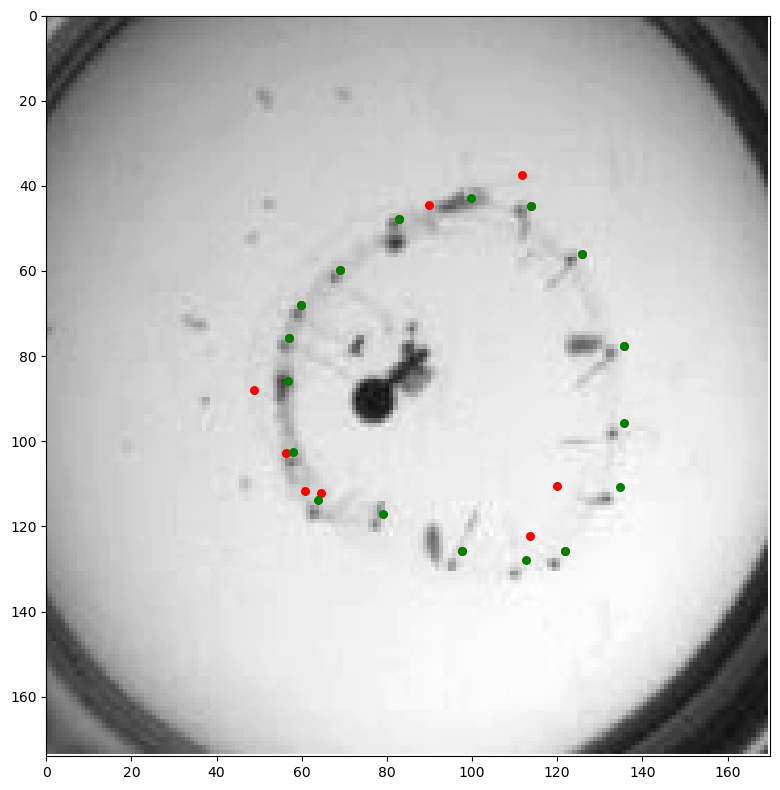

In [19]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}
interp_test_animation_path = '/home/mingxiao/Desktop/animation/interp_test_animation.mp4'
animate_classification_results(pred_result_interpolated, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                               bg_video=vid, bg_video_start_idx=0)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/interp_test_animation_id_assigned_only.mp4
Animation saved to /home/mingxiao/Desktop/animation/interp_test_animation_id_assigned_only.mp4


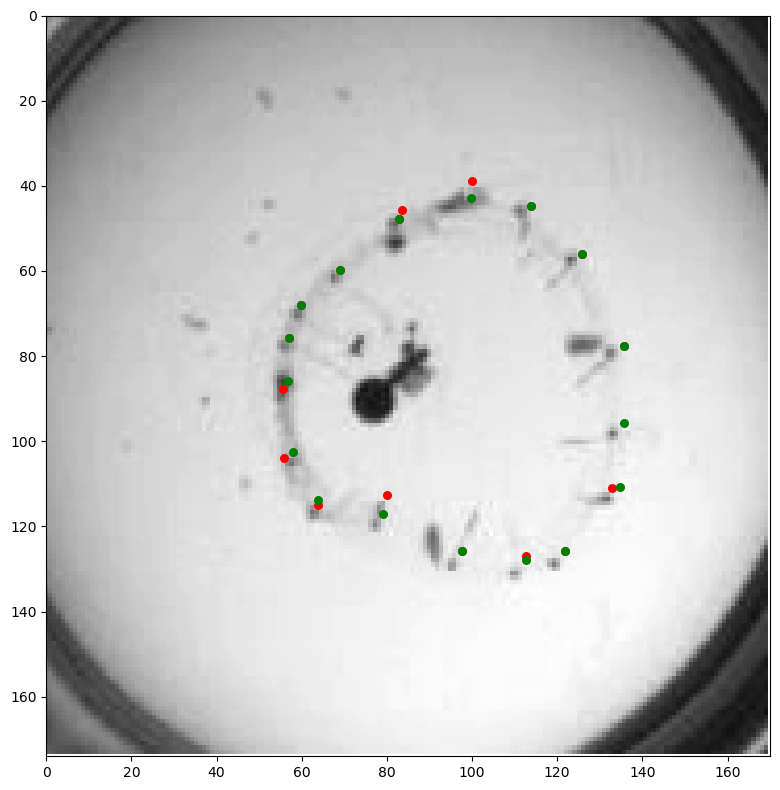

In [20]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}
interp_test_animation_path = '/home/mingxiao/Desktop/animation/interp_test_animation_id_assigned_only.mp4'
animate_classification_results(pred_result_w_ids, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                               bg_video=vid, bg_video_start_idx=0)

affix: m10t1
(3000, 17, 2)
INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/r5/ae_result_m10t1.mp4
Animation saved to /home/mingxiao/Desktop/animation/r5/ae_result_m10t1.mp4
affix: m10t2
(3000, 17, 2)
INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/r5/ae_result_m10t2.mp4
Animation saved to /home/mingxiao/Desktop/animation/r5/ae_result_m10t2.mp4
affix: m10t3
(3000, 17, 2)
INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplot

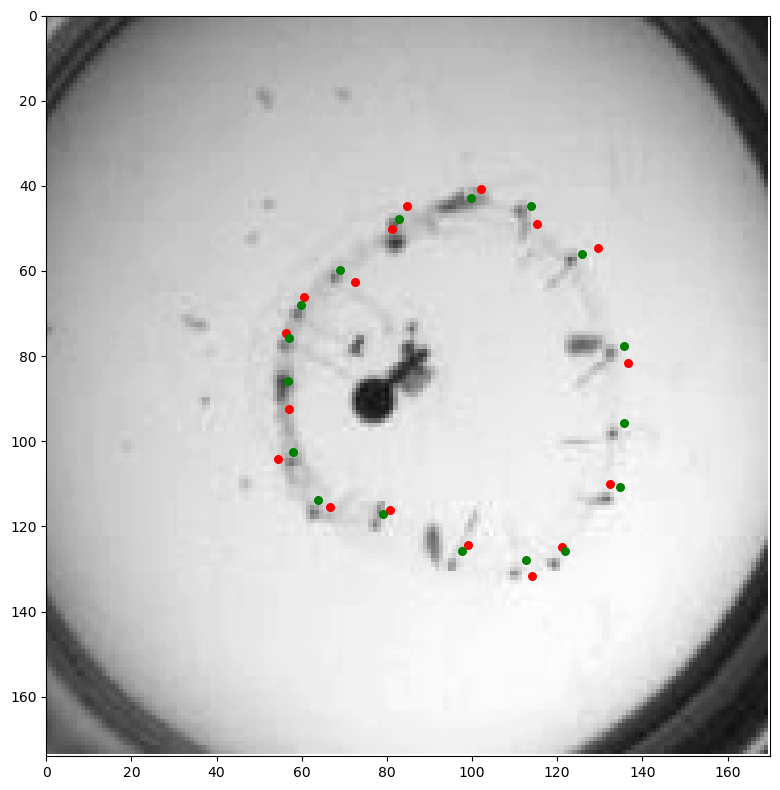

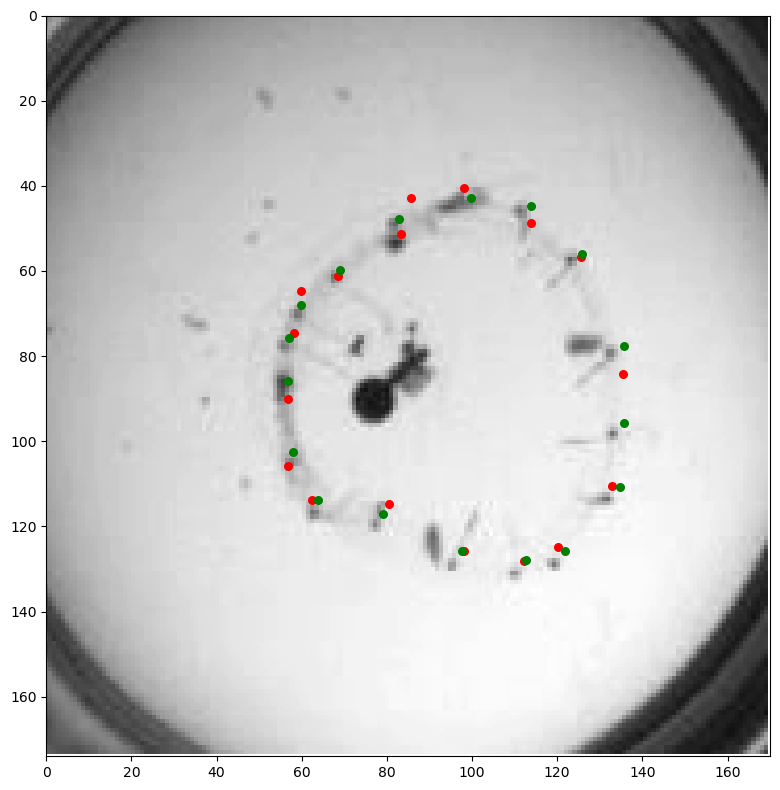

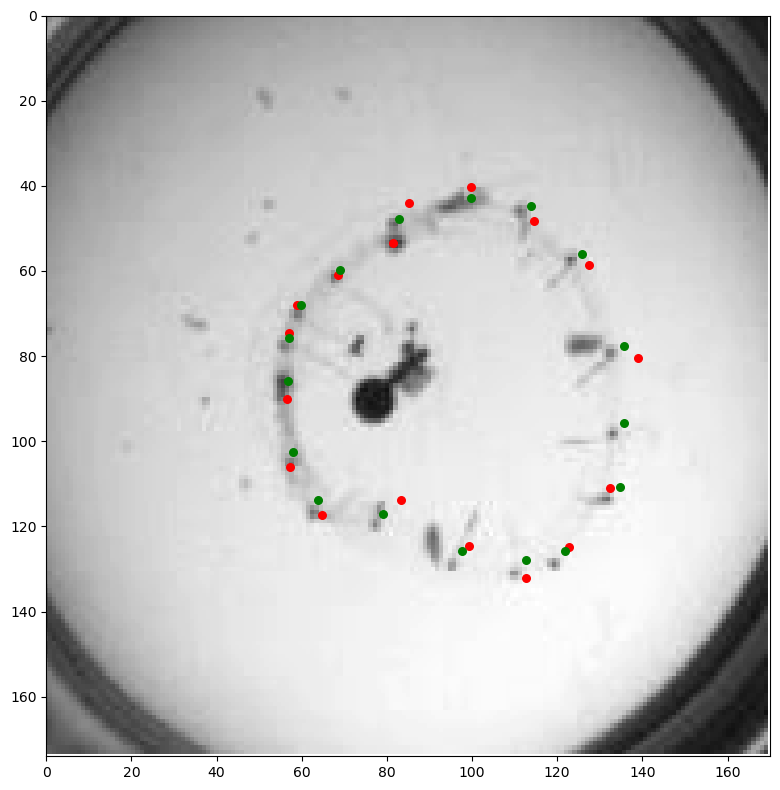

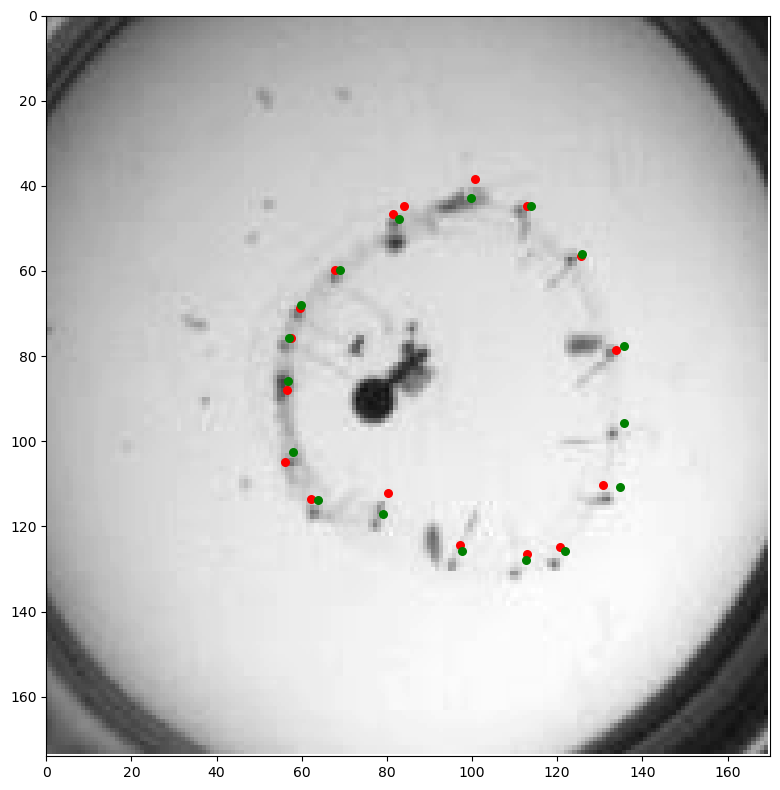

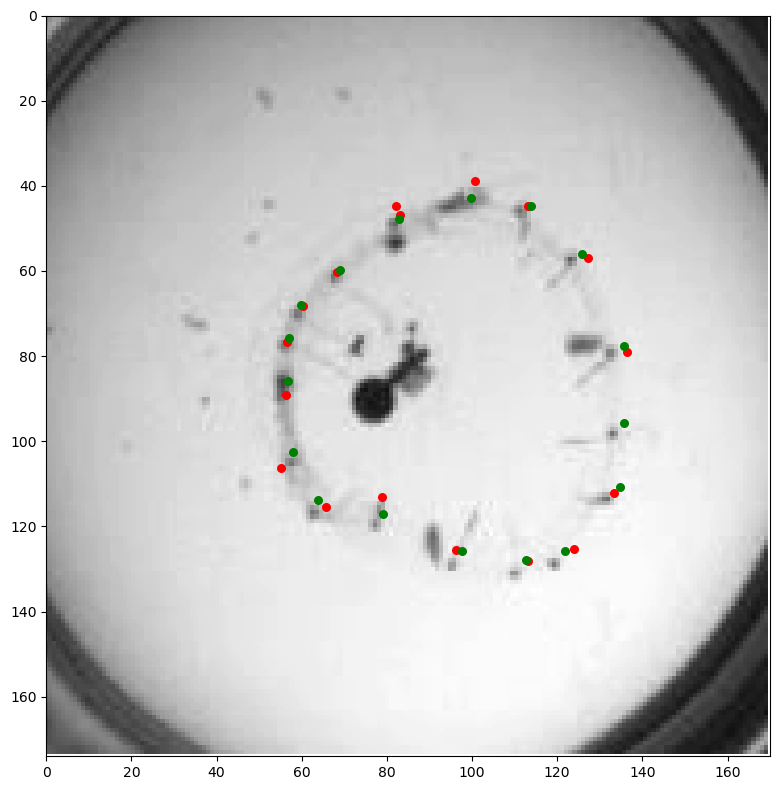

In [18]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}

results_affix = ['m10t1', 'm10t2', 'm10t3', 'm11t1', 'm11t2']
all_predicted_pointss = []
results_dir = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/autoencoder/results/r5'
existing_results = os.listdir(results_dir)
for affix in results_affix:
    print(f'affix: {affix}')
    denoised_coords = np.load(os.path.join(results_dir, f'prediction_{affix}.npy'))
    print(denoised_coords.shape)
    interp_test_animation_path = f'/home/mingxiao/Desktop/animation/r5/ae_result_{affix}.mp4'
    animate_classification_results(denoised_coords, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                                   bg_video=vid, bg_video_start_idx=0)

## eval ae results

In [2]:
results_affix = ['m10t1', 'm10t2', 'm10t3', 'm11t1', 'm11t2']
all_predicted_pts = []
results_dir = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/autoencoder/results/r5'
existing_results = os.listdir(results_dir)
for affix in results_affix:
    print(f'affix: {affix}')
    denoised_coords = np.load(os.path.join(results_dir, f'prediction_{affix}.npy'))
    all_predicted_pts.append(denoised_coords)

affix: m10t1
affix: m10t2
affix: m10t3
affix: m11t1
affix: m11t2


affix: m10t1


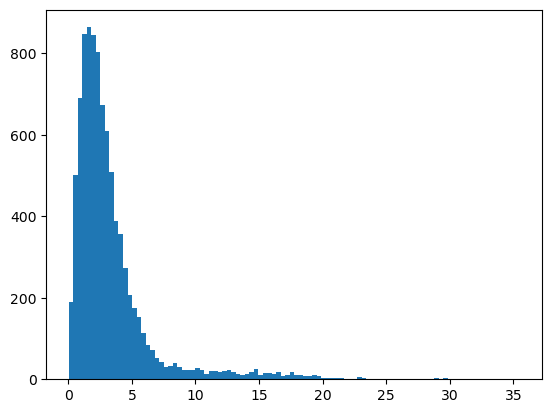

mean: 3.357644667533958, std: 3.3494136169880004, max: 35.49932243061178
affix: m10t2


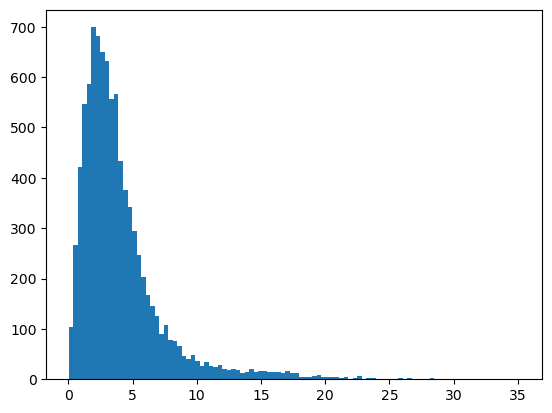

mean: 4.062597259884605, std: 3.4167406461699894, max: 35.158526133293726
affix: m10t3


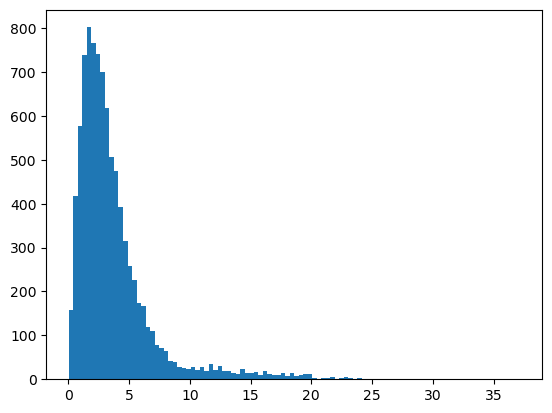

mean: 3.7168679296494216, std: 3.4064895136512168, max: 37.16402341854108
affix: m11t1


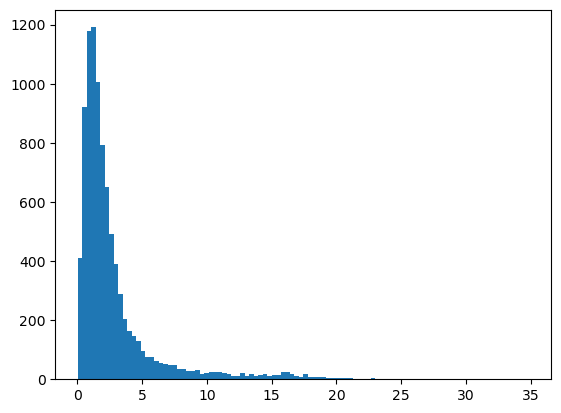

mean: 2.7987562656608755, std: 3.4182191042905172, max: 34.85064562604273
affix: m11t2


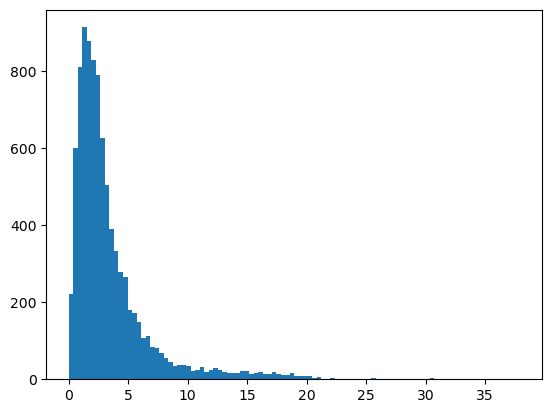

mean: 3.5099629072904195, std: 3.5639273604075217, max: 37.914903758917895


In [24]:
for affix, pred_pts in zip(results_affix, all_predicted_pts):
    print(f'affix: {affix}')
    plot_nn_err(pred_pts, id_missing_mask=id_missing_mask, gt_pts=gt_pts, use_non_overlap_nn=True)


In [14]:
pred_track_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred_simplemax.slp'
pred_track_dataset = sleap.load_file(pred_track_dataset_path)
pred_track_pts = get_all_tracked_points(pred_track_dataset, interpolate=False, use_labeled_only=False, reorder=False, start_idx=0)
print(pred_track_pts.shape)
pred_track_pts_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred_simplemax_pts.npy'
np.save(pred_track_pts_path, pred_track_pts)

all_tracked_points shape: (3000, 17, 2)
First non missing frame idx: 0
Missing point count: 28
(3000, 17, 2)


affix: m10t1


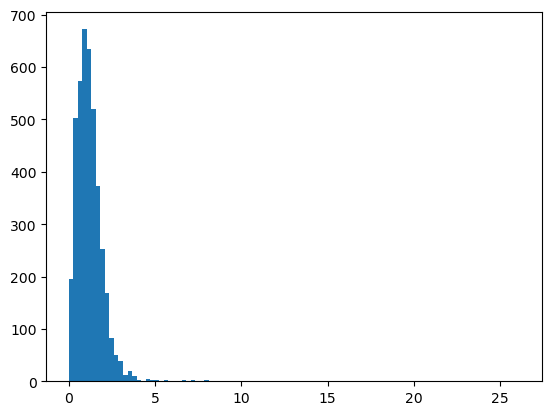

mean: 1.2575067897237877, std: 1.1448525998728316, max: 26.13709182007574


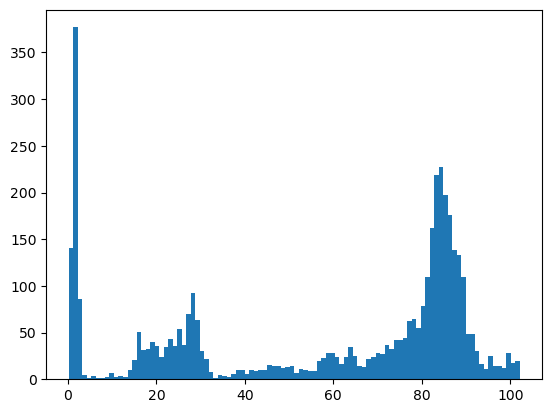

mean: 57.55898799754695, std: 33.18807471223079, max: 102.1576614380834


In [15]:
results_affix = ['m10t1']
all_predicted_pts_r6 = []
results_dir = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/autoencoder/results/r6'
existing_results = os.listdir(results_dir)
for affix in results_affix:
    print(f'affix: {affix}')
    denoised_coords = np.load(os.path.join(results_dir, f'prediction_{affix}.npy'))
    all_predicted_pts_r6.append(denoised_coords)
    plot_nn_err(denoised_coords, id_missing_mask=id_missing_mask, gt_pts=gt_pts, use_non_overlap_nn=True)
    plot_poly_err(denoised_coords, id_missing_mask=id_missing_mask, gt_pts=gt_pts)